# E4 — Coupled $\phi^4$ chain (24D)

**Target.** $q_i\in\mathbb R^2$, $N_s=12$ periodic sites, $\delta=1/N_s$, $\kappa=2.5$:
$$V(q) = \frac{\kappa}{2\delta}\sum_i\|q_{i+1}-q_i\|^2 + \delta\sum_i W(q_i),\qquad W(x,y) = (x^2-1)^2+(y^2-1)^2-0.0125\,xy+0.0075\,x+0.015\,y.$$
Four coherent phases $(\pm1,\pm1)$; for homogeneous fields $V(\mathbf 1\otimes v)=W(v)$, so the coherent barrier equals the barrier of $W$ ($\beta\cdot\min$ barrier $=7.8$), and the kink-pair cost $5.96\gg1$ makes **the coherent flip the minimum-energy path**. The tilt terms are chosen so the inter-phase asymmetry is $\beta\Delta W = 0.44 \le 0.5$: inside the regime where the tamed fixed-step integrator realises the correction's detailed-balance return flux (at $\beta\Delta W\approx1.8$ a measured, $\Delta t$-independent occupancy offset of order $10\%$ appears — a deliberate benchmark-design choice, recorded here). Phase masses remain distinguishably non-uniform, $p^\star \approx (0.323, 0.212, 0.238, 0.227)$. Init at the $--$ phase; partition = basin of $W$ at $\bar q$. **Reference.** Unweighted $W_2$/MMD clouds use finite sampling-importance-resampling (SIR), which is approximate and not i.i.d.; phase masses and scalar energy moments use direct weighted SNIS with proposal diagnostics. A long PT chain provides an independent phase-mass cross-check.

In [1]:
EXPERIMENT = "coupled_phi4"
import os, sys, math, time, json, re, hashlib
sys.path.insert(0, os.path.abspath(".."))
from src.gpu_guard import select_gpu
select_gpu(int(os.environ.get("JCP_GPU", "4")))
import torch
assert torch.cuda.device_count() == 1
torch.set_default_dtype(torch.float64)
import numpy as np
import pandas as pd

from src import config as C
from src.manuscript import manuscript_methods
from src.experiments import (build_e4, make_sampler_factory,
                             make_batched_factory, make_metrics)
from src.runner import (run_experiment_batched, run_one, refine_dt,
                        quadrature_refinement, write_timeseries_csv,
                        write_summary_csv, write_manifest, write_positions_csv,
                        mirror_into_repo,
                        ula_first_passage, hardware_manifest)
from src.samplers import tune_ladder
from src.certificate import make_phi_family, certificate_grid, certificate_importance
from src.plotting import metric_grid
from src.stationarity import (collect_stationary_trajectories,
                              flat_summary_rows, write_stationarity_csv,
                              write_stationarity_npz)

DEV = "cuda"
RUN_ID = os.environ.get("JCP_RUN_ID")
if not RUN_ID:
    RUN_ID = time.strftime("%Y%m%dT%H%M%SZ", time.gmtime()) + f"-p{os.getpid()}"
if (RUN_ID in (".", "..")
        or re.fullmatch(r"[A-Za-z0-9_.-]+", RUN_ID) is None):
    raise ValueError(
        "JCP_RUN_ID must be a safe single component using letters, digits, "
        "dot, underscore, or hyphen")
RESULTS_ROOT = os.path.abspath(os.environ.get(
    "JCP_RESULTS_ROOT", os.path.join("..", "..", "results", "jcp_sampling")))
RUN_ROOT = os.path.join(RESULTS_ROOT, RUN_ID)
EXPERIMENT_ROOT = os.path.join(RUN_ROOT, EXPERIMENT)
RESULTS = os.path.join(EXPERIMENT_ROOT, "artifacts")
FIGURES = os.path.join(RESULTS, "figures")
CACHE = os.path.abspath(os.path.join("..", "cache", EXPERIMENT))
# The launcher owns the experiment directory (logs/status/executed notebook);
# this notebook exclusively creates its immutable artifacts/ leaf beneath it.
# Reusing a run ID across experiments is allowed; artifacts never overwrite.
os.makedirs(RESULTS, exist_ok=False)
os.makedirs(FIGURES, exist_ok=False)
os.makedirs(CACHE, exist_ok=True)
print("RUN_ID:", RUN_ID, "RUN_ROOT:", RUN_ROOT, "RESULTS:", RESULTS)

# Write the requested source configuration before constructing the experiment:
# expensive reference/basin construction failures must still leave provenance.
source_config_path = os.path.join(RESULTS, "original_config.yaml")
_prebuild_config = dict(
    schema_version=1,
    experiment=EXPERIMENT,
    builder_function="build_e4",
    builder_invocation='exp = build_e4(device=DEV, basin_cache=os.path.join(CACHE, "basin_map_v2.npz"))',
    requested_methods=os.environ.get(
        "JCP_METHODS", ",".join(manuscript_methods(EXPERIMENT))).split(","),
    requested_trace_environment=dict(
        JCP_TRACE_SEEDS=os.environ.get("JCP_TRACE_SEEDS", "4"),
        JCP_TRACE_CHAINS=os.environ.get("JCP_TRACE_CHAINS", "8"),
        JCP_TRACE_DRAWS=os.environ.get("JCP_TRACE_DRAWS", "1000"),
        JCP_TRACE_SETTLING_BURN_FRACTION=os.environ.get(
            "JCP_TRACE_SETTLING_BURN_FRACTION", "1.0"),
        JCP_PT_TRACE_BURN_FRACTION=os.environ.get(
            "JCP_PT_TRACE_BURN_FRACTION",
            os.environ.get("JCP_TRACE_SETTLING_BURN_FRACTION", "1.0"))),
    cache_directory=CACHE,
    cache_policy="builder-validated production cache; path and SHA256 recorded after build",
    requested_failure_threshold_environment=dict(
        JCP_MAX_SCORE_CLIP_FRACTION=os.environ.get(
            "JCP_MAX_SCORE_CLIP_FRACTION", "0.01"),
        JCP_MAX_STATE_BOX_CLIP_FRACTION=os.environ.get(
            "JCP_MAX_STATE_BOX_CLIP_FRACTION", "0.01"),
        JCP_MAX_JUMP_BOUNDARY_CLIP_FRACTION=os.environ.get(
            "JCP_MAX_JUMP_BOUNDARY_CLIP_FRACTION", "0.0"),
        JCP_MAX_BASIN_MAP_OUTSIDE_FRACTION=os.environ.get(
            "JCP_MAX_BASIN_MAP_OUTSIDE_FRACTION", "0.001"),
        JCP_MAX_JUMP_CAP_HITS=os.environ.get("JCP_MAX_JUMP_CAP_HITS", "0"),
        JCP_MIN_MALA_ACCEPTANCE=os.environ.get(
            "JCP_MIN_MALA_ACCEPTANCE", "0.05"),
        JCP_MIN_PT_SWAP_ACCEPTANCE=os.environ.get(
            "JCP_MIN_PT_SWAP_ACCEPTANCE", "0.10")),
)
with open(source_config_path, "x", encoding="utf-8") as config_handle:
    config_handle.write("# YAML 1.2 source configuration; created before experiment build\n")
    for config_key, config_value in _prebuild_config.items():
        config_handle.write(
            config_key + ": " + json.dumps(config_value, sort_keys=True,
                                             allow_nan=False) + "\n")
exp = build_e4(device=DEV, basin_cache=os.path.join(CACHE, "basin_map_v2.npz"))
cfg = exp.cfg
_basin_cache_provenance = exp.extras.get("basin_cache_provenance")
if (_basin_cache_provenance is not None
        and _basin_cache_provenance.get("validation_status")
        not in ("validated", "created_validated")):
    raise RuntimeError(
        "production requires a fully metadata-validated basin cache; got "
        + repr(_basin_cache_provenance))
# Method matrix: seven configured methods by default; override with JCP_METHODS
# (comma-separated). The production launcher uses exact+RA for E1/E2 and the
# paired multi-atom estimator for E3/E4.
RUN_METHODS = os.environ.get(
    "JCP_METHODS", ",".join(manuscript_methods(EXPERIMENT))).split(",")

# Declared fail-closed numerical thresholds. Environment overrides are recorded
# in both source and resolved configs; they cannot silently change a run.
FAIL_THRESHOLDS = dict(
    max_score_clip_fraction=float(os.environ.get(
        "JCP_MAX_SCORE_CLIP_FRACTION", "0.01")),
    max_state_box_clip_fraction=float(os.environ.get(
        "JCP_MAX_STATE_BOX_CLIP_FRACTION", "0.01")),
    # Tolerance for pi-targeting LSC-CP methods only (raw CP is recorded, not
    # gated). Zero is unsatisfiable: state-independent jumps give every
    # CP-family sampler a small boundary-contact rate on any finite box
    # (measured LSC-CP rates 2e-4..2e-3 per applied jump at production
    # dynamics config, 2026-07-17 probe).
    max_jump_boundary_clip_fraction=float(os.environ.get(
        "JCP_MAX_JUMP_BOUNDARY_CLIP_FRACTION", "0.01")),
    max_basin_map_outside_fraction=float(os.environ.get(
        "JCP_MAX_BASIN_MAP_OUTSIDE_FRACTION", "0.001")),
    max_jump_cap_hits=int(os.environ.get("JCP_MAX_JUMP_CAP_HITS", "0")),
    min_mala_acceptance=float(os.environ.get(
        "JCP_MIN_MALA_ACCEPTANCE", "0.05")),
    min_pt_swap_acceptance=float(os.environ.get(
        "JCP_MIN_PT_SWAP_ACCEPTANCE", "0.10")),
)
if (not 0.0 <= FAIL_THRESHOLDS["max_score_clip_fraction"] <= 1.0
        or not 0.0 <= FAIL_THRESHOLDS["max_state_box_clip_fraction"] <= 1.0
        or not 0.0 <= FAIL_THRESHOLDS["max_jump_boundary_clip_fraction"] <= 1.0
        or not 0.0 <= FAIL_THRESHOLDS["max_basin_map_outside_fraction"] <= 1.0
        or not 0.0 <= FAIL_THRESHOLDS["min_mala_acceptance"] <= 1.0
        or not 0.0 <= FAIL_THRESHOLDS["min_pt_swap_acceptance"] <= 1.0
        or FAIL_THRESHOLDS["max_jump_cap_hits"] < 0):
    raise ValueError("invalid JCP numerical failure threshold")

# Capture the requested trace settings before any certificate/refinement gate.
# The final resolved config also records the bounded/derived trace protocol.
TRACE_REQUEST = dict(
    seed_count=int(os.environ.get("JCP_TRACE_SEEDS", "4")),
    chains_per_seed=int(os.environ.get("JCP_TRACE_CHAINS", "8")),
    draws=int(os.environ.get("JCP_TRACE_DRAWS", "1000")),
    settling_burn_fraction=float(os.environ.get(
        "JCP_TRACE_SETTLING_BURN_FRACTION", "1.0")),
    pt_burn_fraction=float(os.environ.get(
        "JCP_PT_TRACE_BURN_FRACTION",
        os.environ.get("JCP_TRACE_SETTLING_BURN_FRACTION", "1.0"))),
)
# Freeze the actual model/bank/domain immediately after construction, before
# expensive certificates, reference refinement, or dynamics can fail.  The
# prebuild source file above remains unchanged; all resolved builder/model/
# cache details belong in a separate immutable preflight JSON artifact.
_jump_config = dict(type=type(exp.law).__name__)
if hasattr(exp.law, "atoms"):
    _jump_config.update(
        atoms=exp.law.atoms.detach().cpu().tolist(),
        weights=exp.law.weights.detach().cpu().tolist(),
        shell_half_width=exp.law.h.detach().cpu().tolist())
    if hasattr(exp.law, "jitter_sigma"):
        _jump_config["jitter_sigma"] = float(exp.law.jitter_sigma)
elif hasattr(exp.law, "a") and hasattr(exp.law, "b"):
    _jump_config.update(
        annulus_inner_radius=float(exp.law.a),
        annulus_outer_radius=float(exp.law.b))
_box_config = dict(
    type=type(exp.box).__name__,
    coordinates=("latent" if type(exp.box).__name__ == "LatentRectBox"
                 else "sampling"),
    lower=exp.box.lo.detach().cpu().tolist(),
    upper=exp.box.hi.detach().cpu().tolist())
_cache_artifacts = []
for _cache_name in sorted(os.listdir(CACHE)):
    _cache_path = os.path.join(CACHE, _cache_name)
    if os.path.isfile(_cache_path):
        with open(_cache_path, "rb") as _cache_handle:
            _cache_sha256 = hashlib.sha256(_cache_handle.read()).hexdigest()
        _cache_artifacts.append(dict(
            path=os.path.abspath(_cache_path), sha256=_cache_sha256))
preflight_config = dict(
    schema_version=1,
    experiment=EXPERIMENT,
    source="resolved immediately after experiment/model/cache build",
    source_config_file=os.path.abspath(source_config_path),
    builder=dict(
        function="build_e4", invocation='exp = build_e4(device=DEV, basin_cache=os.path.join(CACHE, "basin_map_v2.npz"))',
        parameters=exp.extras.get("builder_reference_parameters", dict())),
    model=dict(
        experiment_name=exp.name,
        potential_type=type(exp.pot).__name__,
        dimension=cfg.d,
        beta=cfg.beta),
    run_config=dict(
        d=cfg.d, n_particles=cfg.n_particles, T=cfg.T, dt=cfg.dt,
        beta=cfg.beta, eps=cfg.eps, lam=cfg.lam,
        seeds=list(cfg.seeds), n_checkpoints=cfg.n_checkpoints,
        q_theta=cfg.q_theta, q_rho=cfg.q_rho),
    jump_law=_jump_config,
    sampling_box=_box_config,
    sampling_box_design=exp.extras.get("sampling_box_design"),
    cp_drift_cap=float(exp.cp_drift_cap),
    pt_beta_min=float(exp.pt_beta_min),
    reference_and_cache=dict(
        sample_method=exp.extras.get("reference_sample_method", "unspecified"),
        scalar_method=exp.extras.get(
            "reference_scalar_method",
            exp.extras.get("reference_sample_method", "unspecified")),
        builder_parameters=exp.extras.get(
            "builder_reference_parameters", dict()),
        cache_directory=os.path.abspath(CACHE),
        cache_artifacts=_cache_artifacts,
        basin_cache_provenance=_basin_cache_provenance,
        diagnostics=exp.extras.get("reference_diagnostics")),
    requested_methods=list(RUN_METHODS),
    trace_request=TRACE_REQUEST,
    failure_thresholds=FAIL_THRESHOLDS,
    hardware_and_git=hardware_manifest(),
)
preflight_config_path = os.path.join(RESULTS, "resolved_preflight_config.json")
write_manifest(preflight_config_path, **preflight_config)
with open(preflight_config_path, "rb") as _preflight_handle:
    _preflight_config_sha256 = hashlib.sha256(_preflight_handle.read()).hexdigest()
source_config = dict(_prebuild_config)
_reference_basin_map_outside_mass = float(
    exp.extras.get("reference_diagnostics", dict()).get(
        "weighted_basin_map_outside_mass", 0.0))
if (_reference_basin_map_outside_mass
        > FAIL_THRESHOLDS["max_basin_map_outside_fraction"]):
    raise RuntimeError(
        "reference basin-map outside mass %g exceeds declared threshold %g"
        % (_reference_basin_map_outside_mass,
           FAIL_THRESHOLDS["max_basin_map_outside_fraction"]))

CERTIFICATE_TOLERANCE = 1e-6
certificate_result_path = os.path.join(RESULTS, "certificate_result.json")
def persist_certificate_result(report, settings):
    """Persist the measured deployed-quadrature certificate before asserting.

    The gate is the UNCAPPED weak-stationarity residual: it is the identity the
    score field must satisfy. The same integral re-evaluated with the deployed
    M <- min(M, M_MAX) clip is recorded alongside it as a diagnostic, together
    with the clip's effect on the deployed tamed step; see the docstring of
    src.certificate.certificate_grid.
    """
    _max_residual = float(report["max_residual"])
    _payload = dict(
        schema_version=1,
        experiment=EXPERIMENT,
        stage="final gate immediately before production dynamics",
        settings=dict(settings),
        tolerance=CERTIFICATE_TOLERANCE,
        max_residual=_max_residual,
        gated_score_field="uncapped",
        max_residual_capped_score=(
            float(report["max_residual_capped_score"])
            if "max_residual_capped_score" in report else None),
        clip_tamed_step_defect=report.get("clip_tamed_step_defect"),
        m_clip_fraction_grid=report.get("m_clip_fraction_grid"),
        passed=bool(_max_residual < CERTIFICATE_TOLERANCE),
        report=report,
        resolved_preflight_config_file=os.path.abspath(preflight_config_path),
        resolved_preflight_config_sha256=_preflight_config_sha256,
    )
    write_manifest(certificate_result_path, **_payload)
    return _payload

print("wrote immutable source config before build:", source_config_path)
print("wrote resolved preflight config after model/cache build:",
      preflight_config_path, "sha256", _preflight_config_sha256)
print(f"experiment={cfg.name}  d={cfg.d}  N={cfg.n_particles}  T={cfg.T}  dt0={cfg.dt}")
print(f"beta={cfg.beta}  eps={cfg.eps}  lambda={cfg.lam}  seeds={cfg.seeds}")
print("RUN_METHODS:", RUN_METHODS)
print(preflight_config["hardware_and_git"])

RUN_ID: 20260801-wallclock-gpu0 RUN_ROOT: /home/zheyuanlai/levy-sampling-production/results/jcp_sampling/20260801-wallclock-gpu0 RESULTS: /home/zheyuanlai/levy-sampling-production/results/jcp_sampling/20260801-wallclock-gpu0/coupled_phi4/artifacts


wrote immutable source config before build: /home/zheyuanlai/levy-sampling-production/results/jcp_sampling/20260801-wallclock-gpu0/coupled_phi4/artifacts/original_config.yaml
wrote resolved preflight config after model/cache build: /home/zheyuanlai/levy-sampling-production/results/jcp_sampling/20260801-wallclock-gpu0/coupled_phi4/artifacts/resolved_preflight_config.json sha256 8170f672653912d46d8799ca1751c72555eb0fcfef2b29f8ee7b24fa7192b1b9
experiment=coupled_phi4  d=24  N=1000  T=100.0  dt0=0.002
beta=8.0  eps=0.125  lambda=1.0  seeds=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15)
RUN_METHODS: ['ULA', 'MALA', 'FLA', 'BAOAB', 'PT', 'CP', 'LSC-CP', 'LSC-CP-MA']
{'cpu': 'AMD EPYC 9554 64-Core Processor', 'gpu': 'NVIDIA H200 NVL', 'gpu_count_visible': 1, 'cuda_available': True, 'torch': '2.13.0', 'cuda': '13.0', 'python': '3.12.13', 'python_packages': {'numpy': '2.5.1', 'scipy': '1.18.0', 'pandas': '3.0.5', 'matplotlib': '3.11.1', 'nbformat': '5.10.4'}, 'git_commit': '49768e5aef4c

In [2]:
from src.potentials import (PHI4_MINIMA, PHI4_ESCAPE_BARRIERS,
                            PHI4_LAPLACE_MASSES, phi4_W, phi4_W_grad, newton_refine)
V2 = exp.extras["minima_2d"]
for i, ph in enumerate(exp.extras["phases"]):
    v_tab, W_tab = PHI4_MINIMA[ph]
    W = phi4_W(V2[i].unsqueeze(0))[0].item()
    assert abs(V2[i][0].item()-v_tab[0]) < 5e-5 and abs(W - W_tab) < 5e-4
    # p_star is a direct weighted-SNIS estimate; the Laplace table should agree to
    # the anharmonic correction scale (~1e-2)
    assert abs(exp.p_star[i].item() - PHI4_LAPLACE_MASSES[ph]) < 2e-2
print("minima / Laplace masses verified; kink pair cost",
      round(2*exp.pot.kink_energy(), 2), ">> 1.0 coherent barrier")
g = torch.Generator(device=DEV); g.manual_seed(0)
barrier_report = ula_first_passage(exp.pot, exp.box, exp.init_fn(cfg.n_particles, g),
                                   exp.exit_committed, cfg.dt, int(cfg.T/cfg.dt), cfg.eps, g)
barrier_report["kramers_tau_langer"] = exp.kramers_tau
print(f"ULA committed events {barrier_report['event_count']}/"
      f"{barrier_report['n_particles']}; exponential waiting-time MLE "
      f"{barrier_report['exponential_waiting_time_mle']:.0f}, "
      f"KM RMST@T {barrier_report['kaplan_meier_rmst_at_horizon']:.0f}, "
      f"24D Langer time {barrier_report['kramers_tau_langer']:.0f}")

minima / Laplace masses verified; kink pair cost 5.96 >> 1.0 coherent barrier


ULA committed events 3/1000; exponential waiting-time MLE 33315, KM RMST@T 100, 24D Langer time 40376


## Target density: explicit form and visualization

The state is $q=(q_1,\dots,q_{12})\in\mathbb R^{24}$ with sites $q_i=(x_i,y_i)\in\mathbb R^2$, periodic ($q_{13}\equiv q_1$). With $\delta=1/12$, $\kappa=2.5$, $\beta=8$ the target density is, explicitly,

$$\pi(q)\;\propto\;\exp\Big[-\beta\Big(\underbrace{\tfrac{\kappa}{2\delta}}_{=\,15}\sum_{i=1}^{12}\|q_{i+1}-q_i\|^2\;+\;\underbrace{\tfrac{1}{12}}_{=\,\delta}\sum_{i=1}^{12}W(q_i)\Big)\Big],$$
$$W(x,y)=(x^2-1)^2+(y^2-1)^2-0.0125\,xy+0.0075\,x+0.015\,y$$

(un-normalised; $Z$ has no closed form). Structure:

- **Four phases.** $W$ has four minima at $v\approx(\pm1,\pm1)$ (tilt-shifted in the 3rd decimal) with $W$-values $-0.0351\,(--)$, $+0.0050\,(+-)$, $+0.0100\,(++)$, $+0.0200\,(-+)$: inter-phase asymmetries $\beta\Delta W\le0.44$, escape barriers $\beta b\approx7.8$–$8.2$. The global minima of $V$ are the four coherent fields $\mathbf 1\otimes v$.
- **Stiff coupling.** A bond deviation costs $\beta\kappa/(2\delta)=120$ per unit squared distance, so $\pi$ concentrates in four narrow tubes around the coherent fields; the cheapest non-coherent excursion (a kink pair, cost $5.96$) is far above the coherent barrier $\approx1.0$, so phase changes proceed coherently.
- **Slice vs marginal.** On the homogeneous slice $q_i\equiv v$ the coupling term vanishes and $V(\mathbf 1\otimes v)=W(v)$ exactly, so the right panel below ($e^{-\beta W}/Z_W$) is the exact restriction of $\pi$ to the coherent 2-plane. It is a slice, **not** a marginal: the phase masses $p^\star=(0.325,\,0.211,\,0.237,\,0.227)$ are 24D basin integrals estimated by direct weighted SNIS below that also count transverse fluctuations, and agree with the Laplace (harmonic) prediction to $\sim10^{-2}$.

In [3]:
# Target visualization (self-contained, CPU-safe; touches no run state).
# Left: site potential W whose four minima define the coherent phases.
# Right: exact coherent-slice density exp(-beta W)/Z_W -- V(1 (x) v) = W(v),
# so this is pi restricted to the homogeneous 2-plane (a slice, NOT a
# marginal; the exact 24D phase masses also count transverse fluctuations).
import os, sys, math
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import torch
import matplotlib.pyplot as plt
from src.potentials import phi4_W, PHI4_MINIMA, PHI4_LAPLACE_MASSES

beta_viz = 8.0
vg = torch.linspace(-1.9, 1.9, 601, dtype=torch.float64)
VX, VY = torch.meshgrid(vg, vg, indexing="ij")
Wg = phi4_W(torch.stack([VX, VY], dim=-1))
dens_slice = torch.exp(-beta_viz * (Wg - Wg.min()))
dens_slice = dens_slice / (dens_slice.sum() * float(vg[1] - vg[0]) ** 2)

W0 = PHI4_MINIMA["--"][1]
for ph, (v, Wv) in PHI4_MINIMA.items():
    print(f"  phase {ph}: v = ({v[0]:+.4f}, {v[1]:+.4f})   W = {Wv:+.4f}   "
          f"beta*dW vs '--' = {beta_viz*(Wv - W0):.2f}   "
          f"Laplace mass = {PHI4_LAPLACE_MASSES[ph]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), constrained_layout=True)
lv = np.linspace(-0.05, 3.0, 25)
cf0 = axes[0].contourf(vg, vg, Wg.T.clamp(max=3.0), levels=lv, cmap="viridis")
axes[0].contour(vg, vg, Wg.T.clamp(max=3.0), levels=lv, colors="k",
                linewidths=0.25, alpha=0.4)
for ph, (v, Wv) in PHI4_MINIMA.items():
    axes[0].plot(v[0], v[1], "o", ms=5, mfc="w", mec="k")
    axes[0].annotate(f"{ph}: W={Wv:+.3f}", (v[0], v[1]),
                     textcoords="offset points", xytext=(-14, 9),
                     fontsize=8, color="w")
axes[0].set(title=r"site potential $W(x,y)$ (clipped at 3)",
            xlabel="$x$", ylabel="$y$")
fig.colorbar(cf0, ax=axes[0], label="$W$")

cf1 = axes[1].contourf(vg, vg, dens_slice.T, levels=30, cmap="magma")
for ph, (v, _) in PHI4_MINIMA.items():
    axes[1].annotate(f"{ph}: $p^\\star$={PHI4_LAPLACE_MASSES[ph]:.3f}",
                     (v[0], v[1]), textcoords="offset points",
                     xytext=(-18, 10), fontsize=8, color="w")
axes[1].set(title=r"coherent-slice density $e^{-\beta W}/Z_W$ at $\beta=8$"
                  r" (labels: 24D phase masses)",
            xlabel="$x$", ylabel="$y$")
fig.colorbar(cf1, ax=axes[1], label="slice density")
for ext in ("png", "pdf"):
    fig.savefig(os.path.join(FIGURES, "coupled_phi4_target." + ext), dpi=200,
                bbox_inches="tight")
plt.show()

  phase --: v = (-1.0025, -1.0034)   W = -0.0351   beta*dW vs '--' = 0.00   Laplace mass = 0.323
  phase -+: v = (-0.9994, +0.9965)   W = +0.0200   beta*dW vs '--' = 0.44   Laplace mass = 0.212
  phase +-: v = (+0.9975, -1.0003)   W = +0.0050   beta*dW vs '--' = 0.32   Laplace mass = 0.238
  phase ++: v = (+1.0006, +0.9997)   W = +0.0100   beta*dW vs '--' = 0.36   Laplace mass = 0.227


## Jump law and Lévy score (moment-exact)

Homogeneous phase shifts on the **8 edge atoms** of the phase square ($r_a=\mathbf 1_{N_s}\otimes(v_j-v_i)$ for the four edges $\{--\!\leftrightarrow\!-+,\ --\!\leftrightarrow\!+-,\ -+\!\leftrightarrow\!++,\ +-\!\leftrightarrow\!++\}$ in both directions, $w_a=1/8$, shell $h=0.1\min\|r_a\|$). The two **diagonal** pairs $--\!\leftrightarrow\!++$ and $-+\!\leftrightarrow\!+-$ are dropped: their coherent chords pass through the field-zero hilltop at the centre; diagonal transitions relay through a mixed phase in two hops. The gradient energy is exactly invariant under homogeneous shifts, so $V(q-r)-V(q)=\delta\sum_i[W(q_i-d)-W(q_i)]$ is a fixed polynomial in $d$ whose coefficients are the per-particle moments $\sum x_i, \sum x_i^2, \sum x_i^3$ (and $y$ analogues): moments once per step in $O(N_s)$, then every quadrature energy delta is $O(1)$ — **no lattice sweeps** (validated to $10^{-13}$). In 24D the certificate uses the shifted-form identity with importance sampling from the Laplace mixture (equivalent to the deployed score; the $M$ cap never fires on the sampled region). *Optional isotropic jitter* $r=\mathbf 1_{N_s}\otimes(v_j-v_i)+\sigma\xi$ (default $\sigma=0$) is supported only by sampled-bank RA/MA estimators, which use the realised displacement directly; deterministic quadrature and its certificate do not apply when $\sigma>0$.

In [4]:
from src.jumps import gauss_legendre_01
from src.certificate import TanhRidgeProduct
DEFAULT_QUAD = dict(q_theta=C.Q_THETA, q_rho=C.Q_RHO)
phis = make_phi_family(24, exp.extras["means24"][0].tolist(), 1.5, DEV, n_phi=4)
# jump-ALIGNED test functions: in 24D random ridge directions have
# a.r_hat ~ 1/sqrt(24) and are blind to variation along the coherent path,
# which is exactly where the theta-quadrature acts; add ridges along the
# first atoms at three sharpness scales.
for a_idx, sc in ((0, 0.5), (0, 1.0), (2, 0.5)):
    r0 = exp.law.atoms[a_idx]
    rhat = (r0 / r0.norm()).unsqueeze(0)
    mid = exp.extras["means24"][0] + 0.5 * r0
    phis.append(TanhRidgeProduct(rhat, (rhat @ mid.unsqueeze(1)).reshape(1),
                                 torch.tensor([sc], device=DEV)))

def cert_e4(q_theta, q_rho):
    theta, w_theta = gauss_legendre_01(q_theta, DEV)
    shifts, logw = exp.law.quadrature_shifts(q_rho)
    shifts_j, logw_j = exp.law.quadrature_shifts(64)
    return certificate_importance(exp.pot, shifts, logw, theta, w_theta,
                                  cfg.lam, cfg.beta, phis, exp.extras["laplace"],
                                  n_samples=200_000,
                                  nu_shifts_jump=shifts_j, nu_logw_jump=logw_j)

cert_report = cert_e4(**DEFAULT_QUAD)
# E4 uses the shifted importance-sampling form, which never forms M, so it has
# no capped-score diagnostic.
print(f"max R at default orders = {cert_report['max_residual']:.3e}")
print("NOTE: the jump-aligned phis expose the theta-quadrature defect along "
      "the coherent path at Q_theta=16; the refinement gate below selects "
      "the smallest orders with R < 1e-6 (and re-asserts).")
gm = torch.Generator(device=DEV); gm.manual_seed(11)
Mv, _ = exp.make_score(**DEFAULT_QUAD).log_parts(exp.extras["laplace"].sample(100_000, gm))
print(f"max log score magnitude on support: {Mv.max().item():.1f} << 600")
cert_report["max_log_magnitude_on_support"] = float(Mv.max().item())

max R at default orders = 6.763e-05
NOTE: the jump-aligned phis expose the theta-quadrature defect along the coherent path at Q_theta=16; the refinement gate below selects the smallest orders with R < 1e-6 (and re-asserts).
max log score magnitude on support: 11.2 << 600


In [5]:
# PT: geometric ladder beta_k = beta * r^(k-1); K tuned so the post-burn-in
# swap acceptance lands in [0.2, 0.4]
gen = torch.Generator(device=DEV); gen.manual_seed(0)
x0_pilot = exp.init_fn(min(512, cfg.n_particles), gen)
pt_betas, ladder_info = tune_ladder(exp.pot, x0_pilot, cfg.dt, exp.box,
                                    cfg.beta, exp.pt_beta_min, pilot_steps=20_000)
print(f"PT ladder: K={ladder_info['K']}  r={ladder_info['r']:.4f}  "
      f"beta_K={pt_betas[-1].item():.4f}  swap acceptance={ladder_info['swap_acceptance']:.3f}"
      f"  band_attained={ladder_info['band_attained']}")

PT ladder: K=6  r=0.6598  beta_K=1.0000  swap acceptance=0.315  band_attained=True


In [6]:
# frozen reference sample (size N), frozen sliced-W2 projections, frozen MMD
# bandwidth (median heuristic on the reference); bias floors from 20
# independent reference pairs. EMC convention: exp(H(p_hat))/K for uniform
# p*, 1 - EJS(p_hat, p*) otherwise -- near 1 is better in both cases.
metrics_fn, floors, aux = make_metrics(exp, cfg.n_particles)
emc_target = exp.emc_target
print("p_star:", np.round(exp.p_star.cpu().numpy(), 6),
      " uniform:", exp.uniform_target)
print("MMD bandwidth:", round(aux["bandwidth"], 4))
print("reference sample:", aux["sample_reference_method"],
      " scalar reference:", aux["scalar_reference_method"],
      " energy histogram:", aux["energy_reference_method"])
print("FES:", aux["fes_dim"], "D,", aux["fes_bins_per_dim"],
      "bins/dim, support threshold", aux["fes_pi_min"],
      "reference-weighted RMSE in kBT; reference:",
      aux["fes_reference_method"])
if aux.get("reference_diagnostics"):
    print("reference diagnostics:", aux["reference_diagnostics"])
for k, v in floors.items():
    print(f"  floor {k:>12s}: {v['mean']:.5f} +- {v['std']:.5f}")

# SNIS proposal quality + PT cross-check of the direct-SNIS phase masses
g_ess = torch.Generator(device=DEV); g_ess.manual_seed(555)
ess = exp.extras["laplace"].snis_ess_fraction(exp.pot, cfg.beta, g_ess)
print(f"SNIS proposal ESS fraction: {ess:.3f}")
gen_x = torch.Generator(device=DEV); gen_x.manual_seed(4242)
from src.samplers import ParallelTempering
from src.metrics import occupancy
pt_x = ParallelTempering(exp.pot, exp.init_fn(1000, gen_x), cfg.dt, pt_betas,
                         gen_x, exp.box)
for _ in range(int(round(300.0 / cfg.dt))):
    pt_x.step()
p_pt = occupancy(exp.labels_fn(pt_x.positions()), 4).cpu().numpy()
print("long-PT phase masses:", np.round(p_pt, 3),
      " vs direct-SNIS p*:", np.round(exp.p_star.cpu().numpy(), 3))
pt_crosscheck = p_pt.tolist()

p_star: [0.323132 0.211286 0.239409 0.226174]  uniform: False
MMD bandwidth: 1.9468
reference sample: sampling_importance_resampling  scalar reference: direct_snis  energy histogram: direct_snis_weighted_histogram
FES: 2 D, 10 bins/dim, support threshold 0.001 reference-weighted RMSE in kBT; reference: direct_snis_weighted_histogram
reference diagnostics: {'reference_method': 'self_normalized_importance_sampling', 'n_proposals': 200000, 'proposal_ess': 41181.62474302272, 'proposal_ess_fraction': 0.2059081237151136, 'entropy_ess': 173901.47911620303, 'max_normalized_weight': 0.003598086626749327, 'weight_cv2': 3.8565349533443403, 'nonfinite_log_weight_count': 0, 'weighted_basin_map_outside_mass': 0.0, 'weighted_outside_target_phase_envelope_mass': 0.0, 'weighted_outside_jump_safe_core_mass': 0.0, 'weighted_outside_sampling_box_mass': 0.0}
  floor           W2: 0.13034 +- 0.03521
  floor          MMD: 0.02646 +- 0.01076
  floor           TV: 0.02411 +- 0.01037
  floor          EMC: 0.999

long-PT phase masses: [0.365 0.204 0.234 0.197]  vs direct-SNIS p*: [0.323 0.211 0.239 0.226]


In [7]:
def run_terminal_lsc(**quad):
    f = make_sampler_factory(exp, cfg.dt, pt_betas, score_kwargs=quad)
    n_ = int(round(cfg.T / cfg.dt))
    r_, _ = run_one("LSC-CP", 0, f, n_, n_, cfg.dt, metrics_fn, exp.pot, quiet=True)
    return {k: r_[-1][k] for k in ("W2", "TV", "MMD", "EMC")}

settings = [dict(q_theta=qt, q_rho=qr) for qt in (8, 16, 32) for qr in (4, 8, 16)]
CHOSEN_QUAD, quad_table = quadrature_refinement(
    settings, run_terminal_lsc, lambda **s: cert_e4(**s)["max_residual"], floors)
print("chosen quadrature:", CHOSEN_QUAD)
cert_report = cert_e4(**CHOSEN_QUAD)
certificate_result = persist_certificate_result(cert_report, CHOSEN_QUAD)
print("final certificate result:", certificate_result)
assert certificate_result["passed"], certificate_result
display(pd.DataFrame(quad_table).round(6))

/home/zheyuanlai/levy-sampling-production/src/metrics.py:548: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1784990605524/work/aten/src/ATen/native/BucketizationUtils.h:32.)
  idx = torch.searchsorted(xp, xq).clamp(1, xp.numel() - 1)


chosen quadrature: {'q_theta': 32, 'q_rho': 4}


final certificate result: {'schema_version': 1, 'experiment': 'coupled_phi4', 'stage': 'final gate immediately before production dynamics', 'settings': {'q_theta': 32, 'q_rho': 4}, 'tolerance': 1e-06, 'max_residual': 2.0049160447782046e-07, 'gated_score_field': 'uncapped', 'max_residual_capped_score': None, 'clip_tamed_step_defect': None, 'm_clip_fraction_grid': None, 'passed': True, 'report': {'phi_0': {'residual': 2.3934942554242956e-10, 'jump_term': 0.07751353233854588}, 'phi_1': {'residual': 9.812841818159965e-12, 'jump_term': -0.03365182232041269}, 'phi_2': {'residual': 9.268193979891692e-11, 'jump_term': 0.06517292970247923}, 'phi_3': {'residual': 2.680781511288878e-09, 'jump_term': -0.08713905201703614}, 'phi_4': {'residual': 2.0049160447782046e-07, 'jump_term': 0.06023467066420244}, 'phi_5': {'residual': 1.0655263834964188e-09, 'jump_term': 0.05988083931203418}, 'phi_6': {'residual': 2.0029746128518803e-09, 'jump_term': 0.2801136978354546}, 'max_residual': 2.0049160447782046e-0

,q_theta,q_rho,R,W2,TV,MMD,EMC,pass
0,8,4,0.027422,0.078287,0.019306,0.010443,0.999662,False
1,8,8,0.027422,0.078287,0.019306,0.010443,0.999662,False
2,8,16,0.027422,0.078287,0.019306,0.010443,0.999662,False
3,16,4,0.000067,0.097934,0.025306,0.013666,0.999400,False
4,16,8,0.000068,0.097960,0.025306,0.013670,0.999400,False
5,16,16,0.000068,0.097960,0.025306,0.013670,0.999400,False
6,32,4,0.000000,0.097888,0.025306,0.013660,0.999400,True
7,32,8,0.000000,0.097915,0.025306,0.013664,0.999400,True
8,32,16,0.000000,0.097915,0.025306,0.013664,0.999400,True


In [8]:
# dt rule: largest dyadic dt at which every PI-TARGETING method's terminal
# metrics agree with dt/2 (5% / floor-band / 4-sigma noise guards); FLA and
# raw CP have invariant laws != pi and are recorded but do not gate.
# Production: all seeds batched into one (S*N)-particle ensemble per method.
MAIN_METRICS = ["W2", "TV", "MMD", "EMC"]

def run_terminal_all(dt_):
    n_ = int(round(cfg.T / dt_))
    factory = make_sampler_factory(exp, dt_, pt_betas, score_kwargs=CHOSEN_QUAD)
    out = {}
    for m in RUN_METHODS:
        rows_, _ = run_one(m, 0, factory, n_, n_, dt_, metrics_fn, exp.pot, quiet=True)
        out[m] = {k: rows_[-1][k] for k in MAIN_METRICS}
    print(f"  refine_dt: finished pass at dt={dt_}", flush=True)
    return out

dt_final, dt_table = refine_dt(run_terminal_all, cfg.dt, floors,
                               exclude=("FLA", "CP", "CP-RA"))
print("chosen dt:", dt_final)
for row in dt_table:
    print(row)

n_steps = int(round(cfg.T / dt_final))
steps_per_ck = max(1, n_steps // cfg.n_checkpoints)
# dense-early checkpoint schedule: the nonlocal transient lives in the
# first ~5% of the run; 60 dense + 160 sparse points, identical across
# methods (measurement cadence only -- no protocol change)
from src.runner import checkpoint_schedule
ck_steps = checkpoint_schedule(n_steps)
bfactory = make_batched_factory(exp, dt_final, pt_betas, cfg.seeds,
                                score_kwargs=CHOSEN_QUAD)
t0 = time.time()
rows, method_info = run_experiment_batched(RUN_METHODS, cfg.seeds, bfactory,
                                           n_steps, steps_per_ck, dt_final,
                                           metrics_fn, exp.pot,
                                           cfg.n_particles,
                                           checkpoint_steps=ck_steps)
print(f"production total: {time.time()-t0:.0f}s")

def _diagnostic_max(name, method=None):
    return max((float(row[name]) for row in rows
                if name in row and (method is None or row["method"] == method)),
               default=0.0)

def _method_info_max(name):
    return max((float(info[name]) for info in method_info.values()
                if name in info), default=0.0)

def _method_info_value(method, name, default):
    return float(method_info.get(method, {}).get(name, default))

def _targeting_method_info_max(name):
    return max((float(info[name]) for method, info in method_info.items()
                if method not in ("FLA", "CP", "CP-RA") and name in info),
               default=0.0)

def _targeting_diagnostic_max(name):
    return max((float(row[name]) for row in rows
                if row["method"] not in ("FLA", "CP", "CP-RA")
                and name in row), default=0.0)

def _lsc_cp_method_info_max(name):
    return max((float(info[name]) for method, info in method_info.items()
                if method.startswith("LSC-CP") and name in info), default=0.0)

def _raw_cp_method_info_max(name):
    return max((float(info[name]) for method, info in method_info.items()
                if method.startswith("CP") and name in info), default=0.0)

observed_failure_diagnostics = dict(
    nonfinite_fraction=_diagnostic_max("nonfinite_frac"),
    nonfinite_proposal_count=_method_info_max(
        "nonfinite_proposal_count_cumulative"),
    # Gate the final lifetime ratios saved once per batched method. Taking a
    # max over checkpoint prefixes is not the same estimand because cumulative
    # fractions may decrease as more proposals arrive.
    score_clip_fraction=_method_info_max(
        "score_clip_fraction_cumulative"),
    state_box_clip_fraction=_method_info_max(
        "state_box_clip_fraction_cumulative"),
    # Jumps fire state-independently, so rare multi-jump excursions contact
    # any finite box; a hard-zero gate is unsatisfiable at production scale.
    # Gate pi-targeting LSC-CP methods against the declared tolerance. Raw
    # CP's invariant law != pi and its (larger) boundary-contact rate is part
    # of the documented defect: recorded, not gated, exactly like the dt and
    # basin-map gates.
    jump_boundary_clip_fraction_cp=(
        _lsc_cp_method_info_max(
            "jump_boundary_clip_fraction_per_applied_jump_cumulative")),
    jump_boundary_clip_fraction_raw_cp=(
        _raw_cp_method_info_max(
            "jump_boundary_clip_fraction_per_applied_jump_cumulative")),
    basin_map_outside_fraction_targeting=(
        _targeting_diagnostic_max("basin_map_outside_mass")),
    reference_basin_map_outside_mass=_reference_basin_map_outside_mass,
    jump_cap_hits=_method_info_max("jump_cap_hit_count_cumulative"),
    # Use exact accepted/proposed lifetime ratios from the intended method.
    # PT's within-replica MALA counts remain reported but do not enter the
    # standalone MALA gate.
    mala_acceptance_mean=_method_info_value(
        "MALA", "mala_accept_fraction_cumulative", -1.0),
    pt_swap_acceptance_mean=_method_info_value(
        "PT", "pt_swap_accept_fraction_cumulative", -1.0),
)
if observed_failure_diagnostics["nonfinite_fraction"] != 0.0:
    raise RuntimeError("nonfinite production state/metric fraction is nonzero")
if observed_failure_diagnostics["nonfinite_proposal_count"] != 0.0:
    raise RuntimeError("nonfinite production proposal count is nonzero")
for observed_name, threshold_name in (
        ("score_clip_fraction", "max_score_clip_fraction"),
        ("state_box_clip_fraction", "max_state_box_clip_fraction"),
        ("jump_boundary_clip_fraction_cp",
         "max_jump_boundary_clip_fraction"),
        ("basin_map_outside_fraction_targeting",
         "max_basin_map_outside_fraction"),
        ("reference_basin_map_outside_mass",
         "max_basin_map_outside_fraction"),
        ("jump_cap_hits", "max_jump_cap_hits")):
    observed = observed_failure_diagnostics[observed_name]
    threshold = FAIL_THRESHOLDS[threshold_name]
    if observed > threshold:
        raise RuntimeError("%s=%g exceeds declared %s=%g" %
                           (observed_name, observed, threshold_name, threshold))
# Acceptance floors gate a method's own mixing, so they apply only when that
# method is in this run's matrix. The -1.0 sentinel means "method absent"; when
# the production method set is sharded across GPUs, a shard can legitimately
# lack MALA or PT,
# and its acceptance floor must be skipped rather than fail on the sentinel. A
# method that IS present but produced no acceptance statistic still fails, since
# then the value is a real (nonnegative) ratio below the floor rather than -1.
for observed_name, threshold_name, guard_method in (
        ("mala_acceptance_mean", "min_mala_acceptance", "MALA"),
        ("pt_swap_acceptance_mean", "min_pt_swap_acceptance", "PT")):
    if guard_method not in RUN_METHODS:
        continue
    observed = observed_failure_diagnostics[observed_name]
    threshold = FAIL_THRESHOLDS[threshold_name]
    if observed < threshold:
        raise RuntimeError("%s=%g is below declared %s=%g" %
                           (observed_name, observed, threshold_name, threshold))
print("fail-closed diagnostics:", observed_failure_diagnostics,
      "thresholds:", FAIL_THRESHOLDS)

  refine_dt: finished pass at dt=0.002


  refine_dt: finished pass at dt=0.001


chosen dt: 0.002
{'dt': 0.002, 'pass': True, 'failures': [], 'excluded_deviations': []}


ULA: done in 42.3s (batched 16 seeds)


MALA: done in 63.0s (batched 16 seeds)


...

PT: done in 78.8s (batched 16 seeds)


CP: done in 82.7s (batched 16 seeds)


LSC-CP: done in 216.3s (batched 16 seeds)


LSC-CP-MA: done in 433.0s (batched 16 seeds)


production total: 1007s
fail-closed diagnostics: {'nonfinite_fraction': 0.0, 'nonfinite_proposal_count': 0.0, 'score_clip_fraction': 0.00020884875, 'state_box_clip_fraction': 0.00089028625, 'jump_boundary_clip_fraction_cp': 0.00016019734310203382, 'jump_boundary_clip_fraction_raw_cp': 0.004130313515282847, 'basin_map_outside_fraction_targeting': 0.001, 'reference_basin_map_outside_mass': 0.0, 'jump_cap_hits': 0.0, 'mala_acceptance_mean': 0.89101832375, 'pt_swap_acceptance_mean': 0.31546308} thresholds: {'max_score_clip_fraction': 0.01, 'max_state_box_clip_fraction': 0.01, 'max_jump_boundary_clip_fraction': 0.01, 'max_basin_map_outside_fraction': 0.001, 'max_jump_cap_hits': 0, 'min_mala_acceptance': 0.05, 'min_pt_swap_acceptance': 0.1}


In [9]:
# Uniform scalar trajectories for IAT/ESS/R-hat.
# These are separate from the sparse, nonstationary relaxation checkpoints.
# FLA and E1 Raw-CP are retained as explicitly non-targeting mixing diagnostics:
# their ESS must be interpreted together with (never instead of) target bias.
STATIONARY_METHODS = [m for m in RUN_METHODS
                      if m not in ("CP", "CP-RA")]
if EXPERIMENT == "double_well" and "CP" in RUN_METHODS:
    STATIONARY_METHODS.append("CP")
TRACE_SEED_COUNT = min(len(cfg.seeds), int(os.environ.get("JCP_TRACE_SEEDS", "4")))
TRACE_CHAINS_PER_SEED = int(os.environ.get("JCP_TRACE_CHAINS", "8"))
TRACE_DRAWS_REQUESTED = int(os.environ.get("JCP_TRACE_DRAWS", "1000"))
if TRACE_SEED_COUNT < 1 or TRACE_CHAINS_PER_SEED < 1 or n_steps < 2:
    raise ValueError("stationary traces require >=1 seed/chain and >=2 production steps")
TRACE_SEEDS = tuple(cfg.seeds[:TRACE_SEED_COUNT])
TRACE_DRAWS = min(max(2, TRACE_DRAWS_REQUESTED), n_steps)
TRACE_STEPS_PER_DRAW = max(1, n_steps // TRACE_DRAWS)
TRACE_SETTLING_BURN_FRACTION = float(os.environ.get(
    "JCP_TRACE_SETTLING_BURN_FRACTION", "1.0"))
TRACE_PT_BURN_FRACTION = float(os.environ.get(
    "JCP_PT_TRACE_BURN_FRACTION", str(TRACE_SETTLING_BURN_FRACTION)))
if TRACE_SETTLING_BURN_FRACTION < 0 or TRACE_PT_BURN_FRACTION < 0:
    raise ValueError("stationary settling-burn fractions must be non-negative")
TRACE_SETTLING_BURN = int(round(TRACE_SETTLING_BURN_FRACTION * n_steps))
TRACE_PT_BURN = int(round(TRACE_PT_BURN_FRACTION * n_steps))

trace_factory = make_sampler_factory(
    exp, dt_final, pt_betas, n_particles=TRACE_CHAINS_PER_SEED,
    score_kwargs=CHOSEN_QUAD, reference_init=True)
reference_cv_means = aux["reference_cv_means"]
cv_names = ["x"] if len(reference_cv_means) == 1 else [
    f"cv_{j}" for j in range(len(reference_cv_means))]
reference_method = aux["sample_reference_method"]
# Zero burn for MALA is an explicit opt-in, never inferred from a friendly
# sampler name. The present inverse-CDF/grid/SIR references are numerical or
# approximate; E2's exact unbounded MoG draw is not exactly the box-restricted
# MALA target. Therefore every current experiment receives charged settling.
reference_is_exact_target_draw = bool(
    exp.extras.get("reference_exact_for_mala", False))

_common = dict(
    sampler_factory=trace_factory, seeds=TRACE_SEEDS,
    n_draws=TRACE_DRAWS, steps_per_draw=TRACE_STEPS_PER_DRAW, dt=dt_final,
    labels_fn=exp.labels_fn, energy_fn=exp.pot.V, cv_fn=exp.metric_space,
    counter_source=exp.pot, warmup_steps=C.N_WARMUP_STEPS,
    basin_ids=list(range(exp.p_star.numel())), cv_names=cv_names,
    basin_target_probabilities=exp.p_star.cpu().tolist(),
    reference_energy_mean=aux["reference_energy_mean"],
    reference_cv_means=reference_cv_means,
)
stationarity = {"schema_version": 1, "methods": {}, "collection": {}}

def _collect_stationary_group(key, methods, burn_steps, exact_stationary_start,
                              initialization_method):
    if not methods:
        return
    collected = collect_stationary_trajectories(
        methods=methods, burn_in_steps=burn_steps,
        equilibrium_initialized=exact_stationary_start,
        initialization_method=initialization_method, **_common)
    stationarity["methods"].update(collected["methods"])
    stationarity["collection"][key] = collected["collection"]

# Only target-start MALA begins stationary for its exact discrete-time kernel.
# ULA, BAOAB, and split LSC-CP have finite-step invariant laws that need not be
# pi, so their target draw is NOT a stationary kernel draw: charge a T-length
# settling run before measuring IAT/ESS. With an approximate SIR reference,
# MALA is settled as well. Bias against pi remains beside every ESS value.
_exact_mala = (["MALA"] if reference_is_exact_target_draw
               and "MALA" in STATIONARY_METHODS else [])
_settled_nonpt = [m for m in STATIONARY_METHODS
                  if m != "PT" and m not in _exact_mala]
_collect_stationary_group(
    "exact_target_start_mala", _exact_mala, 0, True,
    reference_method + ":exact_target_draw_for_invariant_MALA")
_collect_stationary_group(
    "charged_settling_non_pt", _settled_nonpt, TRACE_SETTLING_BURN, False,
    reference_method + ":reference_draw_then_charged_kernel_settling")
if "PT" in STATIONARY_METHODS:
    # PT replicates one cold reference draw over the ladder, not the joint
    # tempered equilibrium. Its declared burn is timed and charged.
    _collect_stationary_group(
        "charged_settling_pt", ["PT"], TRACE_PT_BURN, False,
        reference_method + ":cold_draw_replicated_over_ladder_then_charged_settling")

_stationary_rows = []
if stationarity["methods"]:
    _stationary_dir = os.path.join(RESULTS, "stationarity")
    os.makedirs(_stationary_dir, exist_ok=False)
    for _method, _result in stationarity["methods"].items():
        _summary = _result["summary"]
        _raw = _result["raw"]
        write_stationarity_csv(
            os.path.join(_stationary_dir, f"{_method}_summary.csv"), _summary)
        write_stationarity_npz(
            os.path.join(_stationary_dir, f"{_method}_traces.npz"),
            trace_times=_raw["trace_times"], positions_t=_raw["positions_t"],
            labels_t=_raw["labels_t"], energy_t=_raw["energy_t"], cv_t=_raw["cv_t"],
            seed_index=_raw["seed_index"],
            chain_index_within_seed=_raw["chain_index_within_seed"],
            summary=_summary,
            metadata={"experiment": EXPERIMENT, "run_id": RUN_ID, "method": _method})
        _stationary_rows.extend(flat_summary_rows(_summary))
    _stationary_table = pd.DataFrame(_stationary_rows)
    _stationary_table.to_csv(
        os.path.join(_stationary_dir, "all_methods_summary.csv"),
        index=False, mode="x")
else:
    _stationary_dir = None
    _stationary_table = pd.DataFrame()

stationarity_manifest = {
    "methods": {m: r["summary"] for m, r in stationarity["methods"].items()},
    "collection": stationarity["collection"],
    "protocol": {
        "exact_zero_burn_methods": _exact_mala,
        "charged_settling_non_pt_methods": _settled_nonpt,
        "settling_burn_steps": TRACE_SETTLING_BURN,
        "pt_burn_steps": TRACE_PT_BURN,
        "recorded_steps": TRACE_DRAWS * TRACE_STEPS_PER_DRAW,
        "reference_sample_method": reference_method,
        "basin_target_method": aux["scalar_reference_method"],
        "energy_target_method": aux["scalar_reference_method"],
        "cv_target_method": aux["scalar_reference_method"],
        "reference_exact_for_mala": reference_is_exact_target_draw,
        "reference_requires_settling": not reference_is_exact_target_draw,
        "sir_reference_is_approximate": (
            reference_method == "sampling_importance_resampling"),
    },
    "excluded_non_targeting_methods": [m for m in RUN_METHODS
                                         if m == "CP-RA"
                                         or (m == "CP" and EXPERIMENT != "double_well")],
    "non_targeting_mixing_diagnostics": {
        m: {
            "interpretation": "biased-kernel mixing diagnostic; not target ESS",
            "must_report_with_target_bias": True,
        }
        for m in STATIONARY_METHODS if m in ("FLA", "CP")
    },
}
print("stationary trace protocol:", TRACE_SEEDS, TRACE_CHAINS_PER_SEED,
      "chains/seed,", TRACE_DRAWS, "draws, stride", TRACE_STEPS_PER_DRAW,
      "recorded steps", TRACE_DRAWS * TRACE_STEPS_PER_DRAW,
      "settling burn", TRACE_SETTLING_BURN, "PT burn", TRACE_PT_BURN)
if not _stationary_table.empty:
    display(_stationary_table[
        ["method", "kind", "name", "mean", "target", "absolute_bias", "iat",
         "ess", "rhat", "ess_per_second", "ess_per_gradient_eval",
         "ess_per_potential_eval", "ess_per_score_quadrature_eval"]
    ].round(5))

stationary trace protocol: (0, 1, 2, 3) 8 chains/seed, 1000 draws, stride 50 recorded steps 50000 settling burn 50000 PT burn 50000


,method,kind,name,mean,target,absolute_bias,iat,ess,rhat,ess_per_second,ess_per_gradient_eval,ess_per_potential_eval,ess_per_score_quadrature_eval
0,ULA,basin,basin_0,0.40625,0.32313,0.08312,inf,0.00000,4.078534e+15,0.00000,0.00000,NaN,NaN
1,ULA,basin,basin_1,0.25000,0.21129,0.03871,inf,0.00000,5.768845e+15,0.00000,0.00000,NaN,NaN
2,ULA,basin,basin_2,0.15625,0.23941,0.08316,inf,0.00000,6.726510e+15,0.00000,0.00000,NaN,NaN
3,ULA,basin,basin_3,0.18750,0.22617,0.03867,inf,0.00000,2.442977e+16,0.00000,0.00000,NaN,NaN
4,ULA,energy,energy,1.64248,1.50909,0.13339,1.85921,17211.59363,1.002460e+00,92.20946,0.00538,NaN,NaN
5,ULA,cv,cv_0,-0.30501,-0.06655,0.23847,27.37312,1169.02996,1.637330e+00,6.26297,0.00037,NaN,NaN
6,ULA,cv,cv_1,-0.12373,-0.12251,0.00122,30.95921,1033.61807,1.698110e+00,5.53751,0.00032,NaN,NaN
7,MALA,basin,basin_0,0.43722,0.32313,0.11409,285.06769,112.25404,3.005373e+01,0.32590,0.00004,0.00004,NaN
8,MALA,basin,basin_1,0.25028,0.21129,0.03900,285.06769,112.25404,2.624468e+01,0.32590,0.00004,0.00004,NaN
9,MALA,basin,basin_2,0.12500,0.23941,0.11441,inf,0.00000,3.587283e+15,0.00000,0.00000,0.00000,NaN


plotted methods: ['ULA', 'MALA', 'FLA', 'BAOAB', 'PT', 'CP', 'LSC-CP', 'LSC-CP-MA']  labels: {'CP': 'Raw-CP', 'LSC-CP': 'LSC-CP', 'LSC-CP-MA': 'LSC-CP-RA (8)'}


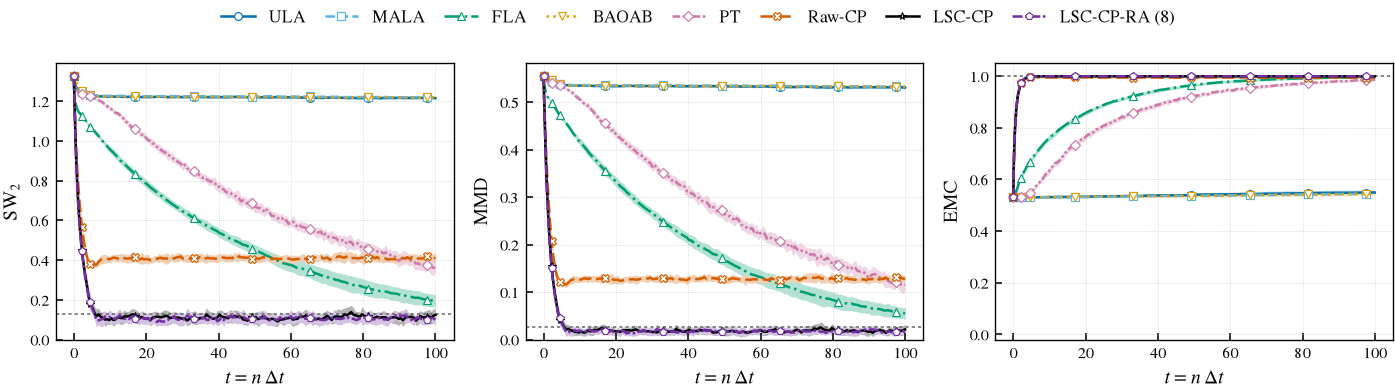

saved: /home/zheyuanlai/levy-sampling-production/results/jcp_sampling/20260801-wallclock-gpu0/coupled_phi4/artifacts/figures/coupled_phi4_metrics.{png,pdf}


saved per-metric log-y figures: ['W2', 'TV', 'MMD', 'FES_RMSE_kBT', 'FES_outside_mass', 'basin_KL_target', 'basin_rel_max', 'KSD', 'W1_cdf', 'CDF_sup', 'pdf_L1', 'KDE_chi2'] x {t, nfe, wallclock}


positions.csv: 129000 rows over 9 blocks (ULA, MALA, FLA, BAOAB, PT, CP, LSC-CP, LSC-CP-MA, reference)


saved density overlays vs reference: ['ULA', 'MALA', 'FLA', 'BAOAB', 'PT', 'CP', 'LSC-CP', 'LSC-CP-MA']


saved 2-D FES maps (shared F ceiling 0.34 kT): ['reference', 'ULA', 'MALA', 'FLA', 'BAOAB', 'PT', 'CP', 'LSC-CP', 'LSC-CP-MA']
stationary diagnostics are in /home/zheyuanlai/levy-sampling-production/results/jcp_sampling/20260801-wallclock-gpu0/coupled_phi4/artifacts/stationarity


In [10]:
from src.plotting import metric_single
from src.runner import convergence_report
# Plotted-method policy: BOTH LSC arms are shown in every experiment -- the
# exact deterministic-quadrature score "LSC-CP" (black) and one realised-
# displacement estimator (purple): single-atom RA on E1/E2, atom-stratified MA
# on E3/E4. The MA arm reads as "LSC-CP-RA (A)" with A the atom count.
PLOT_RAW = "CP" if "CP" in RUN_METHODS else (
    "CP-RA" if "CP-RA" in RUN_METHODS else None)
# Realised LSC arms are one family "LSC-CP-RA (k)" by atoms-per-step k: genuine
# single-atom RA is k=1, multi-atom MA is k=A. E1/E2 (continuous laws) keep the
# plain "LSC-CP-RA".
_ARM_ATOMS = {"mb3well_10d": 4, "coupled_phi4": 8}
def _realised_label(arm):
    A = _ARM_ATOMS.get(EXPERIMENT)
    if arm == "LSC-CP-RA":
        return "LSC-CP-RA (1)" if A else "LSC-CP-RA"
    if arm == "LSC-CP-MA":
        return f"LSC-CP-RA ({A})" if A else "LSC-CP-MA"
    return arm
PLOT_METHODS = [m for m in ("ULA", "MALA", "FLA", "BAOAB", "PT")
                if m in RUN_METHODS]
PLOT_LABELS = {}
if PLOT_RAW is not None:
    PLOT_METHODS.append(PLOT_RAW)
    PLOT_LABELS[PLOT_RAW] = "Raw-CP"
if "LSC-CP" in RUN_METHODS:
    PLOT_METHODS.append("LSC-CP")
    PLOT_LABELS["LSC-CP"] = "LSC-CP"
for _ra in ("LSC-CP-RA", "LSC-CP-MA"):
    if _ra in RUN_METHODS:
        PLOT_METHODS.append(_ra)
        PLOT_LABELS[_ra] = _realised_label(_ra)
print("plotted methods:", PLOT_METHODS, " labels:", PLOT_LABELS)

# The CSV column is always "W2", but only the 1D example computes an exact
# W_2; E2--E4 compute a fixed-projection sliced W_2 into the same column, so
# the figures announce SW_2 there.
fig = metric_grid(rows, os.path.join(FIGURES, EXPERIMENT + "_metrics"),
                  metrics=("W2", "MMD", "EMC"), floors=floors,
                  emc_target=emc_target, methods=PLOT_METHODS,
                  label_overrides=PLOT_LABELS,
                  exact_w2=(EXPERIMENT == "double_well"))
print("saved:", os.path.join(FIGURES, EXPERIMENT + "_metrics") + ".{png,pdf}")

# per-metric log-y single figures on t / NFE / wall-clock axes (all curves start
# at the shared n=0 point; linear x so t=0 / NFE=0 is representable; the cost
# axes are truncated at the largest non-LSC terminal x -- metric_single's
# xmax_mode="baselines" -- so the 10-30x-per-step LSC-CP curve cannot squeeze
# every baseline against the y-axis)
_present = set().union(*[set(r) for r in rows])
# every per-metric figure on disk is regenerated here, so none can go stale
# with old data/axes when the notebook re-runs
_single = [m for m in ("W2", "TV", "TV_density", "MMD",
                       "FES_RMSE_kBT", "FES_outside_mass", "basin_KL_target",
                       "e_F", "basin_rel_max", "KSD", "W1_cdf", "CDF_sup",
                       "pdf_L1", "KDE_chi2", "W2_10d")
           if m in _present and not (m == "e_F" and "FES_RMSE_kBT" in _present)]
for _m in _single:
    for _axis in ("t", "nfe", "wallclock"):
        metric_single(rows, _m, os.path.join(FIGURES, f"{EXPERIMENT}_{_m}_{_axis}"),
                      xaxis=_axis, floors=floors, methods=PLOT_METHODS,
                      emc_target=emc_target, label_overrides=PLOT_LABELS,
                      exact_w2=(EXPERIMENT == "double_well"),
                      show=False)
print("saved per-metric log-y figures:", _single, "x {t, nfe, wallclock}")

# ---- sample-space figures. Terminal samples are persisted FIRST and then read
# ---- back, so these figures are exactly what a CSV-only replot reproduces.
# ---- metric_space maps to the plane the metrics live on (identity for E1/E2,
# ---- latent for E3, qbar for E4).
from src.runner import write_positions_csv
from src.plotting import (load_positions_csv, density_overlay, fes_ceiling,
                          fes_profile_1d, fes_map_2d, REFERENCE_KEY)
_pos = {m: exp.metric_space(method_info[m]["final_positions_all"])[:, :2]
        for m in RUN_METHODS}
_pos[REFERENCE_KEY] = exp.metric_space(aux["ref_x"])[:, :2]
_pos_csv = os.path.join(RESULTS, "positions.csv")
_n_pos = write_positions_csv(_pos, _pos_csv)
print(f"positions.csv: {_n_pos} rows over {len(_pos)} blocks "
      f"({', '.join(_pos)})")
_P = load_positions_csv(_pos_csv)
_dim = _P[REFERENCE_KEY].shape[1]
_plot_pos = [m for m in PLOT_METHODS if m in _P]

for _m in _plot_pos:
    density_overlay(_P, _m, os.path.join(FIGURES, f"{EXPERIMENT}_density_{_m}"),
                    label_overrides=PLOT_LABELS, show=False)
print(f"saved density overlays vs reference: {_plot_pos}")

if _dim == 1:
    fes_profile_1d(_P, os.path.join(FIGURES, f"{EXPERIMENT}_FES_profile"),
                   beta=cfg.beta, methods=_plot_pos,
                   label_overrides=PLOT_LABELS, show=False)
    print("saved 1-D FES profile (true + every method, one figure)")
else:
    _fmax = fes_ceiling(_P, beta=cfg.beta)
    for _m in [REFERENCE_KEY] + _plot_pos:
        fes_map_2d(_P, _m, os.path.join(FIGURES, f"{EXPERIMENT}_FES_{_m}"),
                   beta=cfg.beta, fmax=_fmax, label_overrides=PLOT_LABELS,
                   show=False)
    print(f"saved 2-D FES maps (shared F ceiling {_fmax:.2f} kT): "
          f"{[REFERENCE_KEY] + _plot_pos}")

# R-hat/IAT are deliberately NOT computed from the sparse, nonstationary
# relaxation checkpoints above.  The separate reference-start trace cell
# reports them from uniform post-step scalar trajectories only.
print("stationary diagnostics are in", os.path.join(RESULTS, "stationarity"))

In [11]:
ts_path = os.path.join(RESULTS, "metrics_timeseries.csv")
write_timeseries_csv(rows, ts_path)
summary_metrics = MAIN_METRICS + ["nonfinite_frac", "basin_map_outside_mass"]
summary = write_summary_csv(rows, RUN_METHODS, cfg.seeds, summary_metrics,
                            method_info, floors, os.path.join(RESULTS, "summary.csv"))

write_manifest(
    os.path.join(RESULTS, "resolved_config.json"),
    schema_version=1,
    experiment=EXPERIMENT,
    run_id=RUN_ID,
    source_config_file=os.path.abspath(source_config_path),
    resolved_preflight_config_file=os.path.abspath(preflight_config_path),
    resolved_preflight_config_sha256=_preflight_config_sha256,
    certificate_result_file=os.path.abspath(certificate_result_path),
    results_directory=RESULTS,
    resolved_dt=dt_final,
    resolved_n_steps=n_steps,
    resolved_quadrature=CHOSEN_QUAD,
    resolved_pt_ladder=dict(
        betas=[float(v) for v in pt_betas.detach().cpu()],
        tuning=ladder_info),
    selected_methods=list(RUN_METHODS),
    requested_trace_settings=TRACE_REQUEST,
    stationarity_protocol=stationarity_manifest["protocol"],
    failure_thresholds=FAIL_THRESHOLDS,
    observed_failure_diagnostics=observed_failure_diagnostics,
)

# plot policy recomputed here (not inherited from the figures cell) so the
# manifest is self-contained even if cells are run out of order; it makes
# the immutable timestamped experiment directory sufficient to regenerate
# every figure with no GPU.
# BOTH LSC arms are recorded, matching CELL_FIGURES. The plotting workflow
# reads this manifest block, so a stale list here would silently drop an arm.
_plot_raw = "CP" if "CP" in RUN_METHODS else (
    "CP-RA" if "CP-RA" in RUN_METHODS else None)
_arm_atoms = {"mb3well_10d": 4, "coupled_phi4": 8}
def _realised_label(arm):
    A = _arm_atoms.get(EXPERIMENT)
    if arm == "LSC-CP-RA":
        return "LSC-CP-RA (1)" if A else "LSC-CP-RA"
    if arm == "LSC-CP-MA":
        return f"LSC-CP-RA ({A})" if A else "LSC-CP-MA"
    return arm
_plot_methods = [m for m in ("ULA", "MALA", "FLA", "BAOAB", "PT")
                 if m in RUN_METHODS]
_plot_labels = {}
if _plot_raw is not None:
    _plot_methods.append(_plot_raw)
    _plot_labels[_plot_raw] = "Raw-CP"
if "LSC-CP" in RUN_METHODS:
    _plot_methods.append("LSC-CP")
    _plot_labels["LSC-CP"] = "LSC-CP"
for _ra in ("LSC-CP-RA", "LSC-CP-MA"):
    if _ra in RUN_METHODS:
        _plot_methods.append(_ra)
        _plot_labels[_ra] = _realised_label(_ra)
manifest = dict(
    experiment=EXPERIMENT,
    run_id=RUN_ID,
    results_directory=RESULTS,
    config=dict(d=cfg.d, N=cfg.n_particles, T=cfg.T, dt0=cfg.dt, dt=dt_final,
                beta=cfg.beta, eps=cfg.eps, lam=cfg.lam, seeds=list(cfg.seeds),
                n_checkpoints=cfg.n_checkpoints, warmup_steps=C.N_WARMUP_STEPS,
                batched_seeds=True),
    emc_target=float(emc_target),
    p_star=[float(v) for v in exp.p_star.cpu()],
    plot=dict(methods=_plot_methods, label_overrides=_plot_labels),
    quadrature=dict(chosen=CHOSEN_QUAD, table=quad_table),
    dt_refinement=[{k: (str(v) if isinstance(v, tuple) else v) for k, v in row.items()}
                   for row in dt_table],
    pt_ladder={k: v for k, v in ladder_info.items()},
    certificate=cert_report,
    provenance=dict(
        source_config_file=os.path.abspath(source_config_path),
        resolved_preflight_config_file=os.path.abspath(preflight_config_path),
        resolved_preflight_config_sha256=_preflight_config_sha256,
        certificate_result_file=os.path.abspath(certificate_result_path)),
    bias_floors=floors,
    reference={k: v for k, v in aux.items() if k != "ref_x"},
    stationarity=stationarity_manifest,
    failure_thresholds=FAIL_THRESHOLDS,
    observed_failure_diagnostics=observed_failure_diagnostics,
    barrier_verification=barrier_report,
    method_info={m: {k: v for k, v in mi.items() if isinstance(v, (int, float))}
                 for m, mi in method_info.items()},
    hardware=hardware_manifest(),
    pt_phase_mass_crosscheck=pt_crosscheck,
)
write_manifest(os.path.join(RESULTS, "manifest.json"), **manifest)
print("wrote", ts_path)

# Mirror the evidence and figures into the repository tree. The immutable run
# directory stays the source of truth; this keeps root results/ and figures/
# on the latest run instead of silently going stale,
# which previously required copying every artifact across by hand.
_mirror = mirror_into_repo(RESULTS, EXPERIMENT, os.path.abspath(".."))
print(f"mirrored -> {_mirror['results_dir']} ({len(_mirror['files'])} files), "
      f"{_mirror['figures_dir']} ({_mirror['figure_files']} figures)")

from IPython.display import display
display(pd.read_csv(os.path.join(RESULTS, "summary.csv")).round(5))

wrote /home/zheyuanlai/levy-sampling-production/results/jcp_sampling/20260801-wallclock-gpu0/coupled_phi4/artifacts/metrics_timeseries.csv
mirrored -> /home/zheyuanlai/levy-sampling-production/results/coupled_phi4 (12 files), /home/zheyuanlai/levy-sampling-production/figures/coupled_phi4 (110 figures)


,method,EMC_mean,EMC_std,FES_RMSE_kBT_mean,FES_RMSE_kBT_std,FES_outside_mass_mean,FES_outside_mass_std,MMD_mean,MMD_std,TV_mean,...,pt_swap_accept_fraction_cumulative,pt_swap_proposal_count_cumulative,score_clip_count_cumulative,score_clip_fraction_cumulative,score_quad_evals_per_step,state_box_clip_count_cumulative,state_box_clip_fraction_cumulative,time_to_threshold_TV,wallclock_mean_s,wallclock_std_s
0,ULA,0.54943,0.00967,2.41936,0.08200,0.00000,0.00000,0.53094,0.00193,0.67143,...,NaN,NaN,NaN,NaN,0.0,0.0,0.00000,inf,22.53219,0.0
1,MALA,0.54527,0.00485,2.44944,0.04149,0.00000,0.00000,0.53260,0.00183,0.67299,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,inf,43.17789,0.0
2,FLA,0.99599,0.00152,1.12435,0.03748,0.00006,0.00025,0.05490,0.01257,0.05995,...,NaN,NaN,NaN,NaN,0.0,712229.0,0.00089,inf,27.08268,0.0
3,BAOAB,0.54512,0.00657,2.45225,0.04501,0.00000,0.00000,0.53228,0.00241,0.67299,...,NaN,NaN,NaN,NaN,0.0,0.0,0.00000,inf,24.38875,0.0
4,PT,0.98616,0.00272,1.06335,0.05581,0.00000,0.00000,0.11518,0.01216,0.11867,...,0.31546,200000000.0,NaN,NaN,0.0,NaN,NaN,inf,59.00040,0.0
5,CP,0.99403,0.00216,2.08467,0.02679,0.20894,0.00897,0.12789,0.00615,0.07733,...,NaN,NaN,NaN,NaN,0.0,6592.0,0.00001,4.068,63.04339,0.0
6,LSC-CP,0.99918,0.00064,1.32129,0.12580,0.00362,0.00193,0.02155,0.01033,0.02816,...,NaN,NaN,166144.0,0.00021,16384000.0,116.0,0.00000,4.408,196.78596,0.0
7,LSC-CP-MA,0.99947,0.00048,1.29390,0.08830,0.00288,0.00150,0.01624,0.00656,0.02194,...,NaN,NaN,167079.0,0.00021,4096000.0,142.0,0.00000,4.408,413.45835,0.0
